# 08 — UrbClim 100 m resolution: does finer temperature data break population dominance?

**Motivation:** Notebook 07 found that person-day rankings for Salvador are nearly
identical to pure population rankings — heat-day variation at 1 km is too small
relative to population variation to shift neighbourhood ranks.  The hypothesis
tested here is that the 1 km GSHTD temperature grid lacks sufficient intra-city
thermal contrast: a finer-resolution dataset might reveal enough heat-day
variation to compete with population in the person-days product.

**Data:** UrbClim (De Ridder et al., 2015) daily maximum near-surface air temperature
at **100 m** for Salvador, 2008–2017.  Source files in
`../data/urbClim_salvador/T2M_year_daily_max_YYYY.nc`, CRS EPSG:32724 (UTM 24S).

**Population:** WorldPop 100 m constrained total population (EPSG:4326), reprojected
to the UrbClim UTM grid at runtime.  Per-year cache files written by notebook 02.

**Prerequisites:** `01_data_acquisition` (population), `02_compute_baselines`
(100m per-year population export).

## Setup

In [5]:
!pip install rasterstats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 11.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [rasterstats] [fiona]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import xarray as xr
import geopandas as gpd
import rioxarray          # noqa: F401  — activates .rio accessor
from rasterio.transform import Affine
from rasterstats import zonal_stats
from scipy.stats import spearmanr
from pathlib import Path

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import compute_tx90p_threshold, load_neighbourhood_boundaries

URBCLIM_DIR = '../data/urbClim_salvador'
DATA_DIR    = 'data'
URBCLIM_CRS = 'EPSG:32724'
WGS84       = 'EPSG:4326'
UC_YEARS    = list(range(2008, 2018))   # UrbClim coverage
ABS_THRESH  = 30.0                      # °C, same as notebook 07
PERCENTILE  = 90

print(f'UrbClim years : {UC_YEARS[0]}–{UC_YEARS[-1]}')
print(f'Abs threshold : {ABS_THRESH} °C')
print(f'CRS           : {URBCLIM_CRS}')

UrbClim years : 2008–2017
Abs threshold : 30.0 °C
CRS           : EPSG:32724


## Section 1 — Load UrbClim temperature

Ten annual files are concatenated into a single `(time, y, x)` DataArray.
T2M is in Kelvin; we subtract 273.15 to convert to °C.

In [7]:
files = sorted(glob.glob(f'{URBCLIM_DIR}/T2M_year_daily_max_*.nc'))
print(f'Found {len(files)} UrbClim files: {[Path(f).stem for f in files]}')

ds_uc  = xr.open_mfdataset(files, combine='by_coords')
da_uc  = (ds_uc['T2M'] - 273.15).rename('tmax')   # K → °C
da_uc.attrs['units'] = 'degC'

print(f'\nShape : {dict(zip(da_uc.dims, da_uc.shape))}')
print(f'Period: {str(da_uc.time.values[0])[:10]} to {str(da_uc.time.values[-1])[:10]}')
print(f'T range: {float(da_uc.min()):.1f} – {float(da_uc.max()):.1f} °C')
print(f'x range: {float(da_uc.x.min()):.0f} – {float(da_uc.x.max()):.0f} m')
print(f'y range: {float(da_uc.y.min()):.0f} – {float(da_uc.y.max()):.0f} m')

Found 10 UrbClim files: ['T2M_year_daily_max_2008', 'T2M_year_daily_max_2009', 'T2M_year_daily_max_2010', 'T2M_year_daily_max_2011', 'T2M_year_daily_max_2012', 'T2M_year_daily_max_2013', 'T2M_year_daily_max_2014', 'T2M_year_daily_max_2015', 'T2M_year_daily_max_2016', 'T2M_year_daily_max_2017']

Shape : {'time': 3653, 'y': 201, 'x': 201}
Period: 2008-01-01 to 2017-12-31
T range: 21.7 – 36.5 °C
x range: 548354 – 568354 m
y range: 8558332 – 8578332 m


## Section 2 — Compute TX90p calendar-day threshold

Applies the ETCCDI TX90p approach (centred 5-day window, 90th percentile)
to the UrbClim baseline period (2008–2017, 10 years).  The shorter baseline
compared to notebook 02 (18 years) is a caveat — noted in the interpretation.

Result shape: `(percentile, dayofyear, y, x)`.  Saved to
`data/salvador_urbclim_tx90p_thresh.nc` for reuse.

In [8]:
thresh_path = Path(DATA_DIR) / 'salvador_urbclim_tx90p_thresh.nc'

if thresh_path.exists():
    thresh_uc = xr.open_dataset(thresh_path)['tmax']
    print(f'Loaded from cache: {thresh_path}')
else:
    print('Computing TX90p threshold (may take a few minutes)…')
    thresh_uc = compute_tx90p_threshold(da_uc, window=5, per=[90, 95])
    thresh_uc.to_dataset(name='tmax').to_netcdf(thresh_path)
    print(f'Saved: {thresh_path}')

print(f'Shape : {dict(zip(thresh_uc.dims, thresh_uc.shape))}')
print(f'Range : {float(thresh_uc.min()):.1f} – {float(thresh_uc.max()):.1f} °C')

Loaded from cache: data/salvador_urbclim_tx90p_thresh.nc
Shape : {'percentile': 2, 'y': 201, 'x': 201, 'dayofyear': 366}
Range : 25.2 – 35.5 °C


## Section 3 — Load and reproject WorldPop 100 m population

WorldPop is in EPSG:4326 (geographic lat/lon).  We reproject each year's
100 m slice onto the UrbClim UTM grid using `rioxarray.reproject_match()`
so that the two grids align exactly for pixel-wise multiplication.

The per-year 100 m population files (`data/salvador_pop_100m_YYYY.nc`) were
written by notebook 02.  Reprojected grids are cached to
`data/salvador_pop_100m_utm_YYYY.nc` to avoid repeating the warp.

In [9]:
# Build a reference DataArray on the UrbClim grid for reproject_match
da_uc_ref = da_uc.isel(time=0).drop_vars('time')
da_uc_ref = da_uc_ref.rio.write_crs(URBCLIM_CRS)

pop_utm = {}   # year → DataArray on UrbClim grid

for yr in UC_YEARS:
    cache = Path(DATA_DIR) / f'salvador_pop_100m_utm_{yr}.nc'
    if cache.exists():
        pop_utm[yr] = xr.open_dataset(cache)['population']
        print(f'{yr}: loaded from cache')
        continue

    src_path = Path(DATA_DIR) / f'salvador_pop_100m_{yr}.nc'
    if not src_path.exists():
        # Fall back to stacked population file
        pop_stack = xr.open_dataset(Path(DATA_DIR) / 'salvador_population.nc')['population']
        pop_yr = pop_stack.sel(year=yr).drop_vars('year')
    else:
        pop_yr = xr.open_dataset(src_path)['population']

    # Set source CRS and reproject
    pop_yr = pop_yr.rio.write_crs(WGS84)
    pop_yr = pop_yr.rio.set_spatial_dims(x_dim='lon', y_dim='lat')
    warped  = pop_yr.rio.reproject_match(
        da_uc_ref,
        resampling=5,   # rasterio.enums.Resampling.sum — preserves headcount
    ).rename('population')

    warped.to_dataset().to_netcdf(cache)
    pop_utm[yr] = warped
    print(f'{yr}: reprojected and saved  (total pop = {float(warped.sum()):,.0f})')

print('\nAll population grids ready.')

2008: loaded from cache
2009: loaded from cache
2010: loaded from cache
2011: loaded from cache
2012: loaded from cache
2013: loaded from cache
2014: loaded from cache
2015: loaded from cache
2016: loaded from cache
2017: loaded from cache

All population grids ready.


## Section 4 — Annual heat-day maps at 100 m

For each year compute two per-pixel heat-day counts:
- **Absolute**: days where Tmax ≥ 30 °C (same fixed threshold as notebook 07)
- **TX90p**: days where Tmax exceeds the calendar-day 90th percentile computed above

In [11]:
def count_doy_exceedances_uc(da, thresh_doy):
    """Count days exceeding a (dayofyear, y, x) threshold. Works with UrbClim x/y dims."""
    doy      = da.time.dt.dayofyear
    aligned  = thresh_doy.sel(dayofyear=doy)
    aligned['time'] = da.time
    return (da > aligned).sum(dim='time')

abs_hd  = {}   # year → (y, x)
tx90p_hd = {}  # year → (y, x)

thresh_90 = thresh_uc.sel(percentile=PERCENTILE)

for yr in UC_YEARS:
    da_yr = da_uc.sel(time=da_uc.time.dt.year == yr)
    abs_hd[yr]   = (da_yr >= ABS_THRESH).sum(dim='time').rename('abs_heat_days')
    tx90p_hd[yr] = count_doy_exceedances_uc(da_yr, thresh_90).rename('tx90p_heat_days')

# Multi-year mean maps
abs_hd_mean   = xr.concat(list(abs_hd.values()),   dim='year').mean('year')
tx90p_hd_mean = xr.concat(list(tx90p_hd.values()), dim='year').mean('year')

print('Absolute heat days (multi-year mean):')
print(f'  min={float(abs_hd_mean.min()):.1f}  max={float(abs_hd_mean.max()):.1f}')
print(f'  CV = {float(abs_hd_mean.std()/abs_hd_mean.mean()):.3f}')
print('TX90p heat days (multi-year mean):')
print(f'  min={float(tx90p_hd_mean.min()):.1f}  max={float(tx90p_hd_mean.max()):.1f}')
print(f'  CV = {float(tx90p_hd_mean.std()/tx90p_hd_mean.mean()):.3f}')

Absolute heat days (multi-year mean):
  min=0.4  max=155.5
  CV = 0.815
TX90p heat days (multi-year mean):
  min=33.1  max=37.4
  CV = 0.015


## Section 5 — Visualise the 100 m thermal landscape

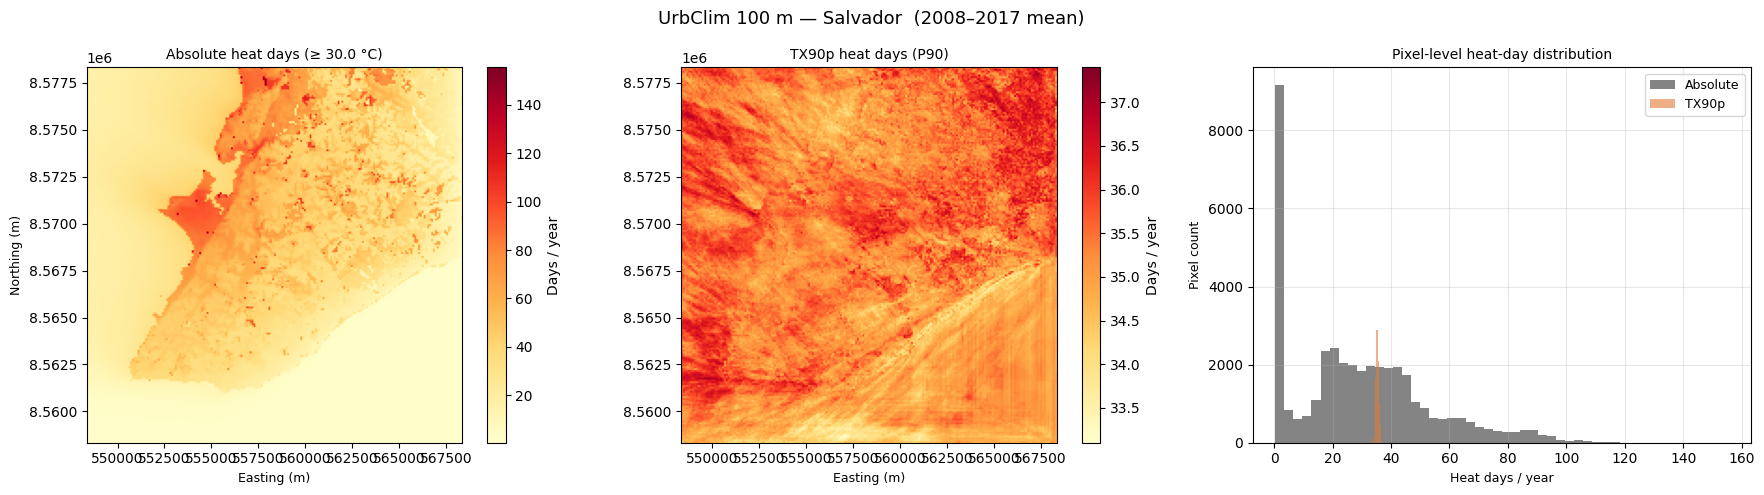

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('UrbClim 100 m — Salvador  (2008–2017 mean)', fontsize=13)

# Map 1: absolute heat days
im0 = axes[0].imshow(
    abs_hd_mean.values, origin='lower',
    extent=[float(da_uc.x.min()), float(da_uc.x.max()),
            float(da_uc.y.min()), float(da_uc.y.max())],
    cmap='YlOrRd',
)
plt.colorbar(im0, ax=axes[0], label='Days / year')
axes[0].set_title(f'Absolute heat days (≥ {ABS_THRESH} °C)', fontsize=10)
axes[0].set_xlabel('Easting (m)', fontsize=9)
axes[0].set_ylabel('Northing (m)', fontsize=9)

# Map 2: TX90p heat days
im1 = axes[1].imshow(
    tx90p_hd_mean.values, origin='lower',
    extent=[float(da_uc.x.min()), float(da_uc.x.max()),
            float(da_uc.y.min()), float(da_uc.y.max())],
    cmap='YlOrRd',
)
plt.colorbar(im1, ax=axes[1], label='Days / year')
axes[1].set_title(f'TX90p heat days (P{PERCENTILE})', fontsize=10)
axes[1].set_xlabel('Easting (m)', fontsize=9)

# Panel 3: pixel-level CV comparison (histogram of heat-day counts)
axes[2].hist(
    abs_hd_mean.values.ravel(),
    bins=50, alpha=0.6, color='#333333', label='Absolute'
)
axes[2].hist(
    tx90p_hd_mean.values.ravel(),
    bins=50, alpha=0.6, color='#e07b39', label='TX90p'
)
axes[2].set_xlabel('Heat days / year', fontsize=9)
axes[2].set_ylabel('Pixel count', fontsize=9)
axes[2].set_title('Pixel-level heat-day distribution', fontsize=10)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 6 — Person-days at 100 m

In [12]:
abs_pd  = {}   # year → (y, x)
tx90p_pd = {}  # year → (y, x)

for yr in UC_YEARS:
    pop = pop_utm[yr]
    # Align population NaNs — UrbClim has a circular domain mask
    mask = ~np.isnan(abs_hd[yr].values)
    pop_masked = pop.where(xr.DataArray(mask, dims=pop.dims, coords=pop.coords))

    abs_pd[yr]   = (abs_hd[yr]   * pop_masked).rename('abs_person_days')
    tx90p_pd[yr] = (tx90p_hd[yr] * pop_masked).rename('tx90p_person_days')

print('Person-day totals (city-wide, 2010 example):')
print(f'  Absolute : {float(abs_pd[2010].sum()):,.0f}')
print(f'  TX90p    : {float(tx90p_pd[2010].sum()):,.0f}')

Person-day totals (city-wide, 2010 example):
  Absolute : 122,875,247
  TX90p    : 80,475,747


## Section 7 — Aggregate to neighbourhoods (zonal statistics)

Neighbourhood boundaries (EPSG:4326) are reprojected to the UrbClim UTM CRS.
`rasterstats.zonal_stats()` then computes per-polygon statistics directly from
the raster arrays without manual pixel assignment:

- **Population**: `sum` — total headcount within the polygon footprint
- **Heat days**: `mean` — mean pixel heat-day count (comparable to notebook 07)
- **Person-days**: `sum` — total person-day burden

The UrbClim domain mask (NaN pixels outside the circular model boundary) is
passed as `nodata` so masked pixels are excluded from every statistic.
Neighbourhoods entirely outside the UrbClim domain return NaN and are dropped.

In [13]:
gdf     = load_neighbourhood_boundaries('salvador', DATA_DIR)
gdf_utm = gdf.to_crs(URBCLIM_CRS)

# Build an affine transform for the UrbClim grid.
# rasterstats expects a north-up array (row 0 = northernmost), so we flipud
# each array before passing it in, and set the y origin to the northern edge.
xs = da_uc.x.values
ys = da_uc.y.values
dx = float(xs[1] - xs[0])   # ~100 m
dy = float(ys[1] - ys[0])   # ~100 m (positive, going north)

affine_transform = Affine(
    dx, 0.0, xs[0] - dx / 2,     # x: west edge, step east
    0.0, -dy, ys[-1] + dy / 2,   # y: north edge, step south (negative)
)

print(f'Grid resolution : {dx:.0f} m × {dy:.0f} m')
print(f'Affine transform: {affine_transform}')

Loaded 22 neighbourhoods from cache: data/geobr_salvador_neighbourhoods_2010.gpkg
Grid resolution : 100 m × 100 m
Affine transform: | 100.00, 0.00, 548304.00|
| 0.00,-100.00, 8578382.00|
| 0.00, 0.00, 1.00|


In [14]:
def zonal(array_2d, stat):
    """Run zonal_stats on a (y, x) array against gdf_utm polygons."""
    return zonal_stats(
        gdf_utm,
        np.flipud(array_2d),   # north-up orientation for rasterstats
        affine=affine_transform,
        stats=[stat],
        nodata=np.nan,
    )

DIAG_YEAR = 2010

pop_arr  = pop_utm[DIAG_YEAR].values
abs_arr  = abs_hd[DIAG_YEAR].values.astype(float)
tx_arr   = tx90p_hd[DIAG_YEAR].values.astype(float)
abs_pd_arr  = abs_pd[DIAG_YEAR].values.astype(float)
tx_pd_arr   = tx90p_pd[DIAG_YEAR].values.astype(float)

df = gdf_utm[['name']].copy().reset_index(drop=True)
df['population'] = [r['sum']  for r in zonal(pop_arr,     'sum')]
df['abs_hd']     = [r['mean'] for r in zonal(abs_arr,     'mean')]
df['tx90p_hd']   = [r['mean'] for r in zonal(tx_arr,      'mean')]
df['abs_pd']     = [r['sum']  for r in zonal(abs_pd_arr,  'sum')]
df['tx90p_pd']   = [r['sum']  for r in zonal(tx_pd_arr,   'sum')]

n_total = len(df)
df = df.dropna().reset_index(drop=True)
n_dropped = n_total - len(df)
if n_dropped:
    print(f'Note: {n_dropped} neighbourhood(s) outside UrbClim domain — excluded.')

for col in ['population', 'abs_hd', 'tx90p_hd', 'abs_pd', 'tx90p_pd']:
    df[f'rank_{col}'] = df[col].rank(ascending=False, method='min').astype(int)

print(f'Neighbourhood table: {len(df)} rows')
print(df[['name', 'population', 'abs_hd', 'tx90p_hd']].sort_values('population', ascending=False).head(8).to_string(index=False))

Note: 1 neighbourhood(s) outside UrbClim domain — excluded.
Neighbourhood table: 21 rows
         name   population     abs_hd  tx90p_hd
  São Caetano 389014.28125  67.378099 41.364876
       Pirajá 326273.03125  63.924083 41.334188
    Amaralina 232939.84375  34.533975 39.682899
Santo Antônio 170782.09375  75.963889 39.569444
       Brotas 170376.56250  58.422399 39.173721
      Valéria 148208.28125  56.686409 40.733167
      Vitória 138745.78125  55.482143 42.081349
        Penha 121467.50000 112.454054 40.122523


## Section 8 — Notebook 07 diagnostic replicated at 100 m

Exact reproduction of the three-panel analysis from notebook 07, but using
100 m UrbClim temperature and WorldPop population for Salvador only.

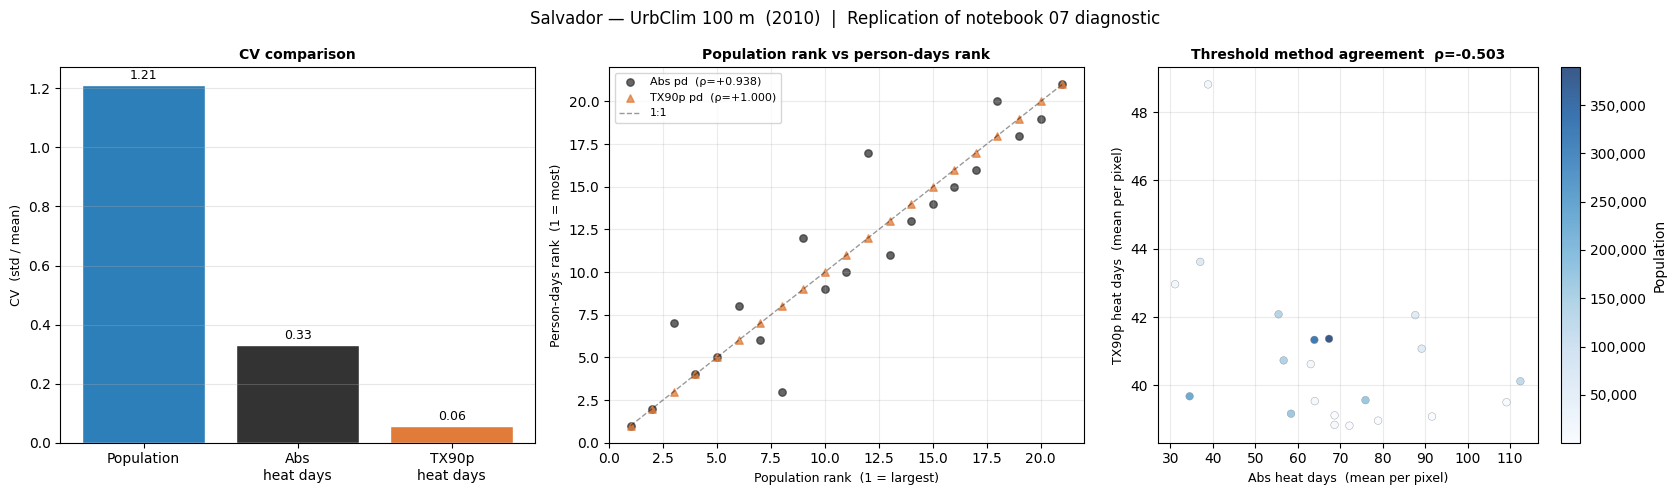

In [21]:
n = len(df)

rho_abs_pd,  _ = spearmanr(df['rank_population'], df['rank_abs_pd'])
rho_tx_pd,   _ = spearmanr(df['rank_population'], df['rank_tx90p_pd'])
rho_abshd_abspd, _ = spearmanr(df['rank_abs_hd'],   df['rank_abs_pd'])
rho_txhd_txpd,   _ = spearmanr(df['rank_tx90p_hd'], df['rank_tx90p_pd'])
rho_hd,          _ = spearmanr(df['abs_hd'],         df['tx90p_hd'])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f'Salvador — UrbClim 100 m  ({DIAG_YEAR})  |  '
    'Replication of notebook 07 diagnostic',
    fontsize=12,
)

# Panel 1: CV bar chart
cv_pop  = df['population'].std() / df['population'].mean()
cv_abs  = df['abs_hd'].std()     / df['abs_hd'].mean()     if df['abs_hd'].mean()   > 0 else 0
cv_tx   = df['tx90p_hd'].std()   / df['tx90p_hd'].mean()   if df['tx90p_hd'].mean() > 0 else 0

bars = axes[0].bar(
    ['Population', 'Abs\nheat days', 'TX90p\nheat days'],
    [cv_pop, cv_abs, cv_tx],
    color=['#2c7fb8', '#333333', '#e07b39'],
    edgecolor='white',
)
for bar, v in zip(bars, [cv_pop, cv_abs, cv_tx]):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('CV  (std / mean)', fontsize=9)
axes[0].set_title('CV comparison', fontsize=10, fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.3)

# Panel 2: population rank vs person-days rank
axes[1].scatter(df['rank_population'], df['rank_abs_pd'],
                s=28, alpha=0.75, color='#333333',
                label=f'Abs pd  (ρ={rho_abs_pd:+.3f})')
axes[1].scatter(df['rank_population'], df['rank_tx90p_pd'],
                s=28, alpha=0.75, color='#e07b39', marker='^',
                label=f'TX90p pd  (ρ={rho_tx_pd:+.3f})')
axes[1].plot([1, n], [1, n], 'k--', lw=1, alpha=0.4, label='1:1')
axes[1].set_xlabel('Population rank  (1 = largest)', fontsize=9)
axes[1].set_ylabel('Person-days rank  (1 = most)', fontsize=9)
axes[1].set_title('Population rank vs person-days rank', fontsize=10, fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.25)

# Panel 3: abs hd vs tx90p hd coloured by population
sc = axes[2].scatter(
    df['abs_hd'], df['tx90p_hd'],
    c=df['population'], cmap='Blues',
    s=30, alpha=0.8, edgecolors='grey', linewidth=0.3,
)
plt.colorbar(sc, ax=axes[2], label='Population',
             format=mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[2].set_xlabel('Abs heat days  (mean per pixel)', fontsize=9)
axes[2].set_ylabel('TX90p heat days  (mean per pixel)', fontsize=9)
axes[2].set_title(f'Threshold method agreement  ρ={rho_hd:+.3f}', fontsize=10, fontweight='bold')
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Section 8b — Sensitivity: population density instead of population count

Person-days using count answers *"where is total burden largest?"* — dominated by
neighbourhood size.  Switching to **density** (person-days per km²) normalises out
area, asking *"where is burden most concentrated per unit space?"*

At 100 m resolution each pixel has the same area, so pixel-level density is a
constant scaling of count and changes nothing.  The meaningful switch is at the
neighbourhood level: divide aggregate person-days by polygon area.

If the urban heat island is real in the UrbClim data, denser and hotter
neighbourhoods should rise together — density may amplify rather than suppress
the heat signal.

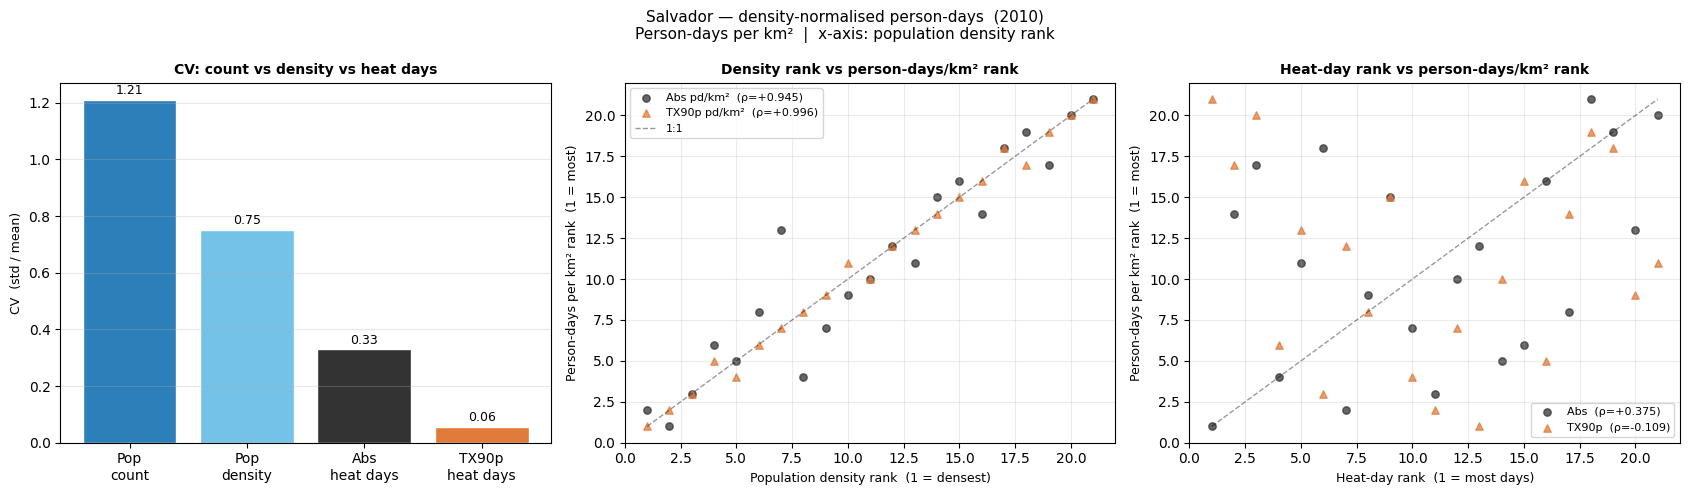


CV summary:
  Population count CV  : 1.210
  Population density CV: 0.752
  Abs heat-day CV      : 0.329
  TX90p heat-day CV    : 0.057


In [22]:
# Neighbourhood areas in km² from the UTM projection (metres → km²)
area_km2 = gdf_utm.set_index('name').loc[df['name']].geometry.area.values / 1e6

df_d = df.copy()
df_d['area_km2']      = area_km2
df_d['pop_density']   = df_d['population'] / df_d['area_km2']
df_d['abs_pd_km2']    = df_d['abs_pd']    / df_d['area_km2']
df_d['tx90p_pd_km2']  = df_d['tx90p_pd']  / df_d['area_km2']

for col in ['pop_density', 'abs_pd_km2', 'tx90p_pd_km2']:
    df_d[f'rank_{col}'] = df_d[col].rank(ascending=False, method='min').astype(int)

cv_dens   = df_d['pop_density'].std()  / df_d['pop_density'].mean()
rho_abs_d,  _ = spearmanr(df_d['rank_pop_density'], df_d['rank_abs_pd_km2'])
rho_tx_d,   _ = spearmanr(df_d['rank_pop_density'], df_d['rank_tx90p_pd_km2'])
rho_abshd_d, _ = spearmanr(df_d['rank_abs_hd'],    df_d['rank_abs_pd_km2'])
rho_txhd_d,  _ = spearmanr(df_d['rank_tx90p_hd'],  df_d['rank_tx90p_pd_km2'])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f'Salvador — density-normalised person-days  ({DIAG_YEAR})\n'
    'Person-days per km²  |  x-axis: population density rank',
    fontsize=11,
)

# Panel 1: CV comparison — count vs density
labels = ['Pop\ncount', 'Pop\ndensity', 'Abs\nheat days', 'TX90p\nheat days']
vals   = [cv_pop, cv_dens, cv_abs, cv_tx]
colors = ['#2c7fb8', '#74c2e8', '#333333', '#e07b39']
bars = axes[0].bar(labels, vals, color=colors, edgecolor='white')
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('CV  (std / mean)', fontsize=9)
axes[0].set_title('CV: count vs density vs heat days', fontsize=10, fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.3)

# Panel 2: density rank vs person-days-per-km² rank
n = len(df_d)
axes[1].scatter(df_d['rank_pop_density'], df_d['rank_abs_pd_km2'],
                s=28, alpha=0.75, color='#333333',
                label=f'Abs pd/km²  (ρ={rho_abs_d:+.3f})')
axes[1].scatter(df_d['rank_pop_density'], df_d['rank_tx90p_pd_km2'],
                s=28, alpha=0.75, color='#e07b39', marker='^',
                label=f'TX90p pd/km²  (ρ={rho_tx_d:+.3f})')
axes[1].plot([1, n], [1, n], 'k--', lw=1, alpha=0.4, label='1:1')
axes[1].set_xlabel('Population density rank  (1 = densest)', fontsize=9)
axes[1].set_ylabel('Person-days per km² rank  (1 = most)', fontsize=9)
axes[1].set_title('Density rank vs person-days/km² rank', fontsize=10, fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.25)

# Panel 3: does heat-day rank now propagate into person-days/km²?
axes[2].scatter(df_d['rank_abs_hd'], df_d['rank_abs_pd_km2'],
                s=28, alpha=0.75, color='#333333',
                label=f'Abs  (ρ={rho_abshd_d:+.3f})')
axes[2].scatter(df_d['rank_tx90p_hd'], df_d['rank_tx90p_pd_km2'],
                s=28, alpha=0.75, color='#e07b39', marker='^',
                label=f'TX90p  (ρ={rho_txhd_d:+.3f})')
axes[2].plot([1, n], [1, n], 'k--', lw=1, alpha=0.4)
axes[2].set_xlabel('Heat-day rank  (1 = most days)', fontsize=9)
axes[2].set_ylabel('Person-days per km² rank  (1 = most)', fontsize=9)
axes[2].set_title('Heat-day rank vs person-days/km² rank', fontsize=10, fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print(f'\nCV summary:')
print(f'  Population count CV  : {cv_pop:.3f}')
print(f'  Population density CV: {cv_dens:.3f}')
print(f'  Abs heat-day CV      : {cv_abs:.3f}')
print(f'  TX90p heat-day CV    : {cv_tx:.3f}')

### Section 8c — Priority quadrant: high hazard × high exposure

Keeps hazard and exposure as separate axes rather than collapsing them into one
metric.  Neighbourhoods in the **top-right quadrant** (above-median heat days
*and* above-median population density) are the intervention priorities.

Quadrant lines are drawn at the **median** of each axis across the 21 neighbourhoods
in the UrbClim domain.  Labels show neighbourhood names for the top-right quadrant.

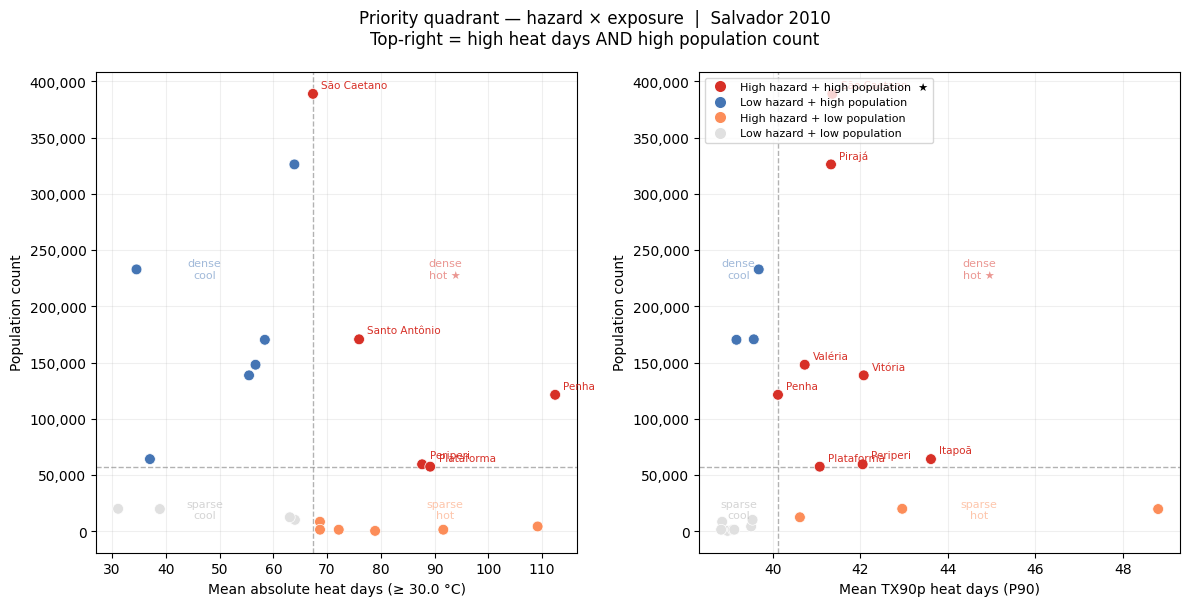


Priority neighbourhoods (above-median hazard AND population) — absolute threshold:
         name  mean heat days    population  area km²
        Penha      112.454054 121467.500000  5.529497
   Plataforma       89.197452  57581.347656  4.682630
     Periperi       87.692211  59672.183594  9.221367
Santo Antônio       75.963889 170782.093750  7.174754
  São Caetano       67.378099 389014.281250 24.216120


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(
    f'Priority quadrant — hazard × exposure  |  Salvador {DIAG_YEAR}\n'
    'Top-right = high heat days AND high population count',
    fontsize=12,
)

haz_cols   = ['abs_hd',   'tx90p_hd']
haz_labels = [f'Mean absolute heat days (≥ {ABS_THRESH} °C)',
              f'Mean TX90p heat days (P{PERCENTILE})']

for ax, haz_col, haz_label in zip(axes, haz_cols, haz_labels):
    x     = df_d[haz_col].values
    y     = df_d['population'].values
    names = df_d['name'].values

    med_x = np.median(x)
    med_y = np.median(y)

    high_haz  = x >= med_x
    high_dens = y >= med_y

    colors_q = np.where(
        high_haz & high_dens,   '#d73027',
        np.where(
            ~high_haz & high_dens,  '#4575b4',
            np.where(
                high_haz & ~high_dens, '#fc8d59',
                '#e0e0e0'
            )
        )
    )

    ax.scatter(x, y, c=colors_q, s=60, edgecolors='white', linewidth=0.5, zorder=3)

    for xi, yi, name, is_priority in zip(x, y, names, high_haz & high_dens):
        if is_priority:
            ax.annotate(name, (xi, yi),
                        textcoords='offset points', xytext=(6, 4),
                        fontsize=7.5, color='#d73027')

    ax.axvline(med_x, color='grey', lw=1, ls='--', alpha=0.6)
    ax.axhline(med_y, color='grey', lw=1, ls='--', alpha=0.6)

    xlo, xhi = ax.get_xlim()
    ylo, yhi = ax.get_ylim()
    kw = dict(fontsize=8, alpha=0.5, ha='center', va='center')
    ax.text(xlo + (med_x - xlo) * 0.5, med_y + (yhi - med_y) * 0.5, 'dense\ncool',   color='#4575b4', **kw)
    ax.text(med_x + (xhi - med_x) * 0.5, med_y + (yhi - med_y) * 0.5, 'dense\nhot ★', color='#d73027', **kw)
    ax.text(xlo + (med_x - xlo) * 0.5, ylo + (med_y - ylo) * 0.5, 'sparse\ncool',    color='#aaaaaa', **kw)
    ax.text(med_x + (xhi - med_x) * 0.5, ylo + (med_y - ylo) * 0.5, 'sparse\nhot',   color='#fc8d59', **kw)

    ax.set_xlabel(haz_label, fontsize=10)
    ax.set_ylabel('Population count', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax.set_aspect('auto')
    ax.grid(True, alpha=0.2)
    ax.set_box_aspect(1)   # force square axes

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d73027', markersize=9, label='High hazard + high population  ★'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4575b4', markersize=9, label='Low hazard + high population'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#fc8d59', markersize=9, label='High hazard + low population'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e0e0e0', markersize=9, label='Low hazard + low population'),
]
axes[1].legend(handles=legend_elements, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

print(f'\nPriority neighbourhoods (above-median hazard AND population) — absolute threshold:')
priority = df_d[
    (df_d['abs_hd']     >= np.median(df_d['abs_hd'])) &
    (df_d['population'] >= np.median(df_d['population']))
].sort_values('abs_hd', ascending=False)
print(priority[['name', 'abs_hd', 'population', 'area_km2']]
      .rename(columns={'abs_hd': 'mean heat days', 'population': 'population', 'area_km2': 'area km²'})
      .to_string(index=False))

## Section 9 — Resolution comparison: 1 km vs 100 m

Side-by-side summary of the key statistics from notebook 07 (1 km GSHTD) and
this notebook (100 m UrbClim), both for Salvador in 2010 or nearest year.

In [18]:
from utils.heat import (
    load_city, load_tx90p_threshold,
    compute_absolute_heat_days, compute_person_days_map,
    aggregate_to_neighbourhoods, aggregate_person_days_to_neighbourhoods,
)

# --- Compute 1 km reference for the same DIAG_YEAR ---
da_1km     = load_city('salvador', DATA_DIR)
da_1km.attrs['units'] = 'degC'
thresh_1km = load_tx90p_threshold('salvador', DATA_DIR)
pop_1km    = xr.open_dataset(f'{DATA_DIR}/salvador_pop_1km_{DIAG_YEAR}.nc')['population']

tx_annual_1km = (
    (da_1km > thresh_1km.sel(percentile=PERCENTILE)
              .sel(dayofyear=da_1km.time.dt.dayofyear))
    .resample(time='YS').sum('time')
)
abs_hd_1km = compute_absolute_heat_days(da_1km, DIAG_YEAR, ABS_THRESH)
tx_hd_1km  = (tx_annual_1km
               .isel(time=(tx_annual_1km.time.dt.year == DIAG_YEAR))
               .squeeze('time'))

df_1km = gdf[['name']].copy().reset_index(drop=True)
df_1km['population'] = aggregate_person_days_to_neighbourhoods(
    pop_1km, gdf, col='population')['population'].values
df_1km['abs_hd']   = aggregate_to_neighbourhoods(
    abs_hd_1km, gdf, col='abs_hd')['abs_hd'].values
df_1km['tx90p_hd'] = aggregate_to_neighbourhoods(
    tx_hd_1km, gdf, col='tx90p_hd')['tx90p_hd'].values
df_1km['abs_pd']   = aggregate_person_days_to_neighbourhoods(
    compute_person_days_map(abs_hd_1km, pop_1km), gdf, col='abs_pd')['abs_pd'].values
df_1km['tx90p_pd'] = aggregate_person_days_to_neighbourhoods(
    compute_person_days_map(tx_hd_1km, pop_1km), gdf, col='tx90p_pd')['tx90p_pd'].values
df_1km = df_1km.dropna().reset_index(drop=True)
for col in ['population', 'abs_hd', 'tx90p_hd', 'abs_pd', 'tx90p_pd']:
    df_1km[f'rank_{col}'] = df_1km[col].rank(ascending=False, method='min').astype(int)

cv_pop_1km = df_1km['population'].std() / df_1km['population'].mean()
cv_abs_1km = df_1km['abs_hd'].std()     / df_1km['abs_hd'].mean()
cv_tx_1km  = df_1km['tx90p_hd'].std()   / df_1km['tx90p_hd'].mean()
rho_abs_1km, _ = spearmanr(df_1km['rank_population'], df_1km['rank_abs_pd'])
rho_tx_1km,  _ = spearmanr(df_1km['rank_population'], df_1km['rank_tx90p_pd'])

# --- Comparison table ---
rows = [
    {
        'Resolution':          f'1 km  (GSHTD)',
        'CV: population':      round(cv_pop_1km, 3),
        'CV: abs heat days':   round(cv_abs_1km, 3),
        'CV: TX90p heat days': round(cv_tx_1km,  3),
        'ρ pop vs abs pd':     round(rho_abs_1km, 3),
        'ρ pop vs TX90p pd':   round(rho_tx_1km,  3),
    },
    {
        'Resolution':          '100 m  (UrbClim)',
        'CV: population':      round(cv_pop, 3),
        'CV: abs heat days':   round(cv_abs, 3),
        'CV: TX90p heat days': round(cv_tx,  3),
        'ρ pop vs abs pd':     round(rho_abs_pd, 3),
        'ρ pop vs TX90p pd':   round(rho_tx_pd,  3),
    },
]

comp = pd.DataFrame(rows).set_index('Resolution')
display(comp.style.format('{:.3f}').set_caption(
    f'Resolution comparison — Salvador  (diagnostic year: {DIAG_YEAR})  |  '
    'ρ = Spearman rank correlation'
))

salvador: shape {'time': 6497, 'lat': 55, 'lon': 67}  2003-01-01 to 2020-12-30
salvador TX90p threshold: shape {'percentile': 3, 'lat': 55, 'lon': 67, 'dayofyear': 365}  window=5  percentiles=[90, 95, 99]  range 26.0–88.4 °C


,CV: population,CV: abs heat days,CV: TX90p heat days,ρ pop vs abs pd,ρ pop vs TX90p pd
Resolution,,,,,
1 km (GSHTD),1.042,0.436,0.747,0.987,0.959
100 m (UrbClim),1.210,0.329,0.057,0.938,1.000


## Interpretation

### What to look for

**If heat-day CV increases substantially at 100 m** (relative to 1 km) but
ρ(pop, person-days) remains near 1, the dominance is structural — population
variation simply exceeds temperature variation at any resolution within Salvador.
The 1 km result was not a resolution artefact.

**If ρ(pop, person-days) drops meaningfully** at 100 m, finer temperature
data does allow heat-day variation to propagate into the person-days product.
In that case the 1 km finding is a resolution artefact and the person-days
metric becomes more informative at 100 m.

### Caveats

- **Baseline period**: the TX90p threshold is derived from 10 years (2008–2017)
  rather than the 18-year GSHTD baseline.  A shorter baseline increases sampling
  uncertainty in the percentile estimate.
- **Domain size**: the UrbClim grid covers a 20 km × 20 km window, which may
  not capture all Salvador neighbourhoods.  Neighbourhoods outside the domain
  are excluded from the comparison.
- **UrbClim coverage**: UrbClim does not cover the full Salvador bounding box
  used in the GSHTD analysis, so the neighbourhood sample sizes may differ.